# MERFISH S2R1 to Allen CCF slice 675

This notebook aligns the adult mouse brain MERFISH S2R1 sample (83,546 cells)
to annotated Allen Common Coordinate Framework (CCF) coronal slice 675. The
reference has no gene-expression features. spAlignDE therefore discovers
correspondences between ST spatial structures and hierarchical atlas regions,
then refines those correspondences with coarse-to-fine S-LDDMM.

The analysis starts from the canonical AnnData produced by the single-
clustering notebook and returns the same AnnData with pre-aligned coordinates,
final aligned coordinates, Allen labels, and package provenance.

## Installation and input data

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,atlas,tutorial]"
```

| Role | Input | Contract |
|---|---|---|
| Query ST | `tutorials/cross_modality/atlas/output/merfish_S2R1_single_clustered.h5ad` | cell-by-gene `X`; coordinates in `obsm["spatial"]`; selected labels in `obs["cluster"]` |
| Atlas annotation | `annotation_10.nrrd` | Allen CCF 2022 annotation volume; this example selects coronal slice 675 |
| Atlas hierarchy | `voxel_count_and_differences.csv` | annotation ID index plus structure name/acronym, hierarchy path, and display color |

Download the Allen CCF 2022 files from the
[Allen Institute annotation release](https://download.alleninstitute.org/informatics-archive/current-release/mouse_ccf/annotation/ccf_2022/)
and place them in `data/allen_ccf_2022/`, or set `SPALIGNDE_ALLEN_CCF_DIR`.
Run the single-clustering notebook first, or set
`SPALIGNDE_CLUSTERED_ST_H5AD` to an equivalent clustered AnnData file.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

import spAlignDE

WORKFLOW_SEED = 1234
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "atlas" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

clustered_default = OUTPUT_DIR / "merfish_S2R1_single_clustered.h5ad"
CLUSTERED_PATH = Path(os.environ.get("SPALIGNDE_CLUSTERED_ST_H5AD", clustered_default)).expanduser()

public_atlas_dir = PROJECT_ROOT / "data" / "allen_ccf_2022"
ATLAS_DIR = Path(os.environ.get("SPALIGNDE_ALLEN_CCF_DIR", public_atlas_dir)).expanduser()

required_atlas_files = [
    ATLAS_DIR / "annotation_10.nrrd",
    ATLAS_DIR / "voxel_count_and_differences.csv",
]
missing_atlas_files = [str(path) for path in required_atlas_files if not path.is_file()]
if missing_atlas_files:
    raise FileNotFoundError(
        "Allen CCF inputs are missing. Place them under data/allen_ccf_2022 "
        "or set SPALIGNDE_ALLEN_CCF_DIR. Missing: " + ", ".join(missing_atlas_files)
    )

adata = spAlignDE.load_single_sample_data(CLUSTERED_PATH)
if "cluster" not in adata.obs and "banksy_cluster_refined" in adata.obs:
    adata.obs["cluster_raw"] = adata.obs["banksy_cluster"].astype(str).astype("category")
    adata.obs["cluster_refined"] = adata.obs["banksy_cluster_refined"].astype(str).astype("category")
    adata.obs["cluster"] = adata.obs["cluster_refined"].copy()

atlas = spAlignDE.load_allen_ccf_reference(
    ATLAS_DIR / "annotation_10.nrrd",
    ATLAS_DIR / "voxel_count_and_differences.csv",
    slice_index=675,
)

print(f"Query: {adata.n_obs:,} cells × {adata.n_vars:,} genes; {adata.obs['cluster'].nunique()} clusters")
print(f"Reference: Allen CCF slice {atlas.slice_index}; image shape {atlas.shape}")

Query: 83,546 cells × 649 genes; 25 clusters
Reference: Allen CCF slice 675; image shape (800, 1140)


## 1. Build coarse-to-fine ST structure levels

Single-sample BANKSY supplies the finest ST labels. spAlignDE then aggregates
log-transformed expression within each cluster, retains genes explaining 80%
of total gene-wise variance (at least 50 genes), standardizes cluster-average
profiles, and applies Ward linkage. Two coarser partitions precede the final
BANKSY partition. Three levels provide the validated coarse-to-fine path. The
structure-pairing score also treats area and thickness as first-class shape
evidence, which helps distinguish narrow laminar regions from broader adjacent
structures. No CA3-specific matching rule is used. The executed output below
is authoritative for the current locked environment.

These levels are ST-only: Allen labels and coordinates are not used to create
them. Atlas hierarchy candidates from depths 2–10 remain eligible at every
stage; only the ST partition becomes finer.

In [2]:
config = spAlignDE.STAtlasAlignmentConfig(
    n_levels=3,
    minimum_coarse_structures=7,
    variance_fraction=0.8,
    min_genes=50,
    stage_iterations=(100, 500, 100),
    restore_best_checkpoint=False,
    continue_alignment=True,
    continue_max_iterations=10,
    continue_min_pair_gain=1,
    continuation_iterations=200,
    pairing_weight_sdf=0.05,
    pairing_weight_chamfer=0.05,
    pairing_weight_dice=0.20,
    pairing_weight_area=0.50,
    pairing_weight_thickness=0.20,
    pairing_dice_soft=0.25,
    continuation_kernel_scale=200,
    continuation_velocity_grid_spacing=50,
    continuation_restore_best_checkpoint=False,
    device=None,  # automatically uses CUDA when available
)

adata, hierarchy_columns = spAlignDE.build_st_cluster_hierarchy(
    adata,
    config=config,
    cluster_key="cluster",
    copy=False,
)
print("Coarse-to-fine alignment labels:", [*hierarchy_columns, "cluster"])
display(
    pd.DataFrame(
        {
            "label column": [*hierarchy_columns, "cluster"],
            "number of structures": [
                *[adata.obs[column].nunique() for column in hierarchy_columns],
                adata.obs["cluster"].nunique(),
            ],
        }
    )
)

Coarse-to-fine alignment labels: ['cluster_level_k7', 'cluster_level_k16', 'cluster']


,label column,number of structures
0,cluster_level_k7,7
1,cluster_level_k16,16
2,cluster,25


## 2. Align ST to the Allen CCF slice

The package performs four linked operations:

1. Estimate rotation, isotropic scale, and translation by maximizing IoU
   between the whole-ST mask and atlas brain mask; reflection is disabled.
2. Rasterize each ST structure as an adaptive smoothed binary mask and compare
   it with atlas structures derived directly from the annotation hierarchy.
3. Select non-overlapping one-to-one correspondences using a gated composite
   of Dice, signed-distance correlation, Chamfer similarity, area similarity,
   and thickness similarity. Average surface distance is retained as QC.
4. Convert accepted mask pairs to matched signed-distance channels and apply
   coarse-to-fine shooting-based LDDMM.

This notebook always performs a fresh alignment from the clustered AnnData.
No validated-result loader or alignment cache is involved.

The default pairing score is

`0.05 × SDF + 0.05 × Chamfer + 0.20 × Dice + 0.50 × area + 0.20 × thickness`.

These weights sum to one. They emphasize global size and laminar thickness
without a structure-name override; Dice, SDF, and Chamfer still require spatial
agreement. Raw ASD is retained only as an independent QC gate. For new data,
follow the [cross-modality pairing-weight tuning guide](https://dsong-lab.github.io/spAlignDE/tutorials/parameter_tuning.html#cross-modality-pairing-weights)
and change the five weights globally while keeping them non-negative and
normalized to one.

[area-only gate] mode=bbox, q=0.4, threshold=2288582.270, n_detail=10


[iter] stage labels: ['cluster_level_k7', 'cluster_level_k16', 'cluster']
[iter] total stages: 3

[stage-1] label_col=cluster_level_k7 | final_stage=False


num prefix candidates: 227
num layer candidates: 6
layers in current slice: ['L1', 'L2/3', 'L4', 'L5', 'L6a', 'L6b']
[1/7] evaluating cluster=1


[2/7] evaluating cluster=2


[3/7] evaluating cluster=3


...

[20/25] evaluating cluster=4


[21/25] evaluating cluster=5
[22/25] evaluating cluster=6
[23/25] evaluating cluster=7
[24/25] evaluating cluster=8


[25/25] evaluating cluster=9


[continue-1] pairs after: 18 | gain: 1


saved continuation visualization PNG: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/continue_alignment/continue_alignment_iter_01_before_after.png
saved continuation visualization PDF: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/continue_alignment/continue_alignment_iter_01_before_after.pdf


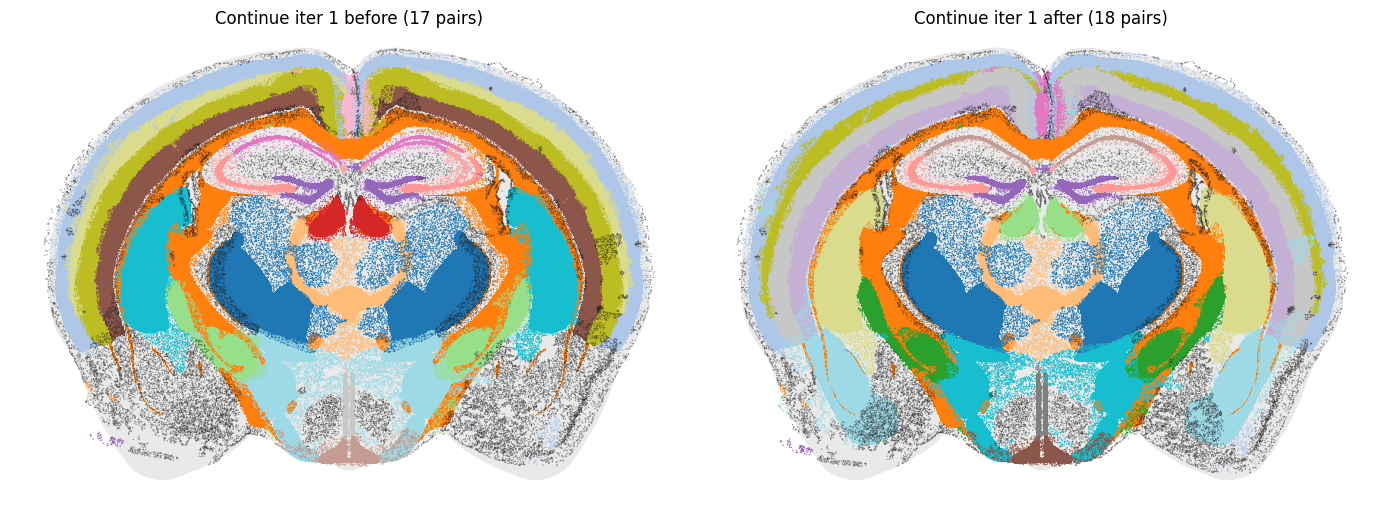


[continue-2] finding pairs before refinement


num prefix candidates: 227
num layer candidates: 6
layers in current slice: ['L1', 'L2/3', 'L4', 'L5', 'L6a', 'L6b']
[1/25] evaluating cluster=0


[2/25] evaluating cluster=1


[3/25] evaluating cluster=10


[4/25] evaluating cluster=11


...

[20/25] evaluating cluster=4


[21/25] evaluating cluster=5
[22/25] evaluating cluster=6
[23/25] evaluating cluster=7
[24/25] evaluating cluster=8


[25/25] evaluating cluster=9


[continue-2] pairs after: 18 | gain: 0


saved continuation visualization PNG: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/continue_alignment/continue_alignment_iter_02_before_after.png
saved continuation visualization PDF: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/continue_alignment/continue_alignment_iter_02_before_after.pdf


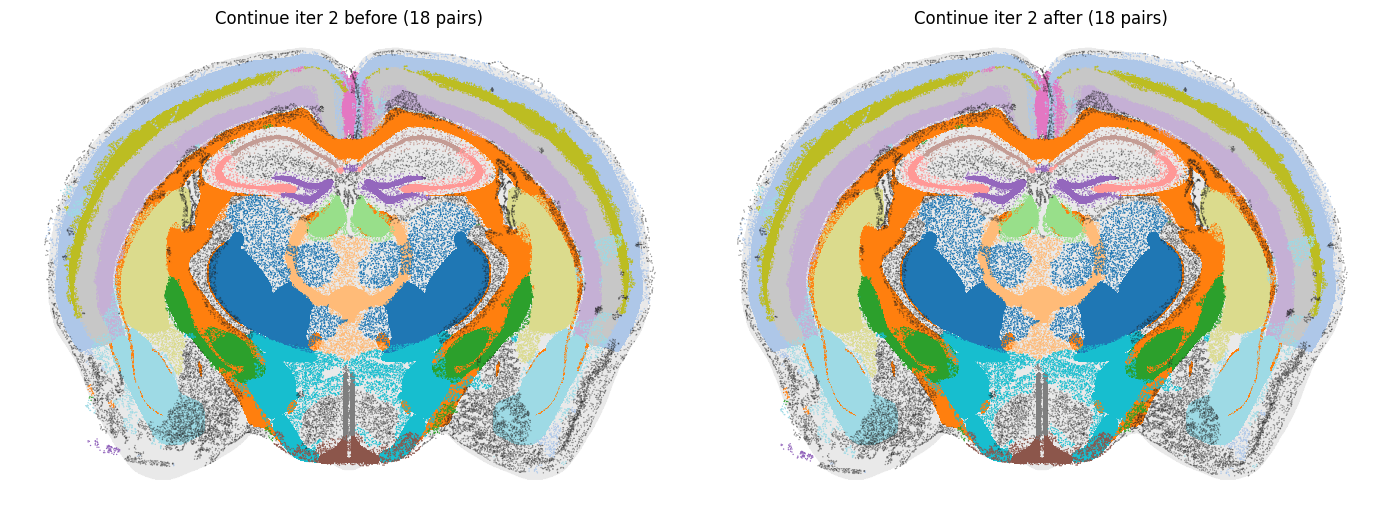


[continue] stop reason: pair_count_not_increased
[continue] saved pair counts: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/continue_alignment/continue_alignment_pair_counts.csv


,iteration,n_pairs_before,n_pairs_after,pair_gain,lddmm_ran,stop
0,1,17,18,1,True,False
1,2,18,18,0,True,True


saved continuation pair-count plot PNG: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/continue_alignment/continue_alignment_pair_counts.png
saved continuation pair-count plot PDF: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/continue_alignment/continue_alignment_pair_counts.pdf


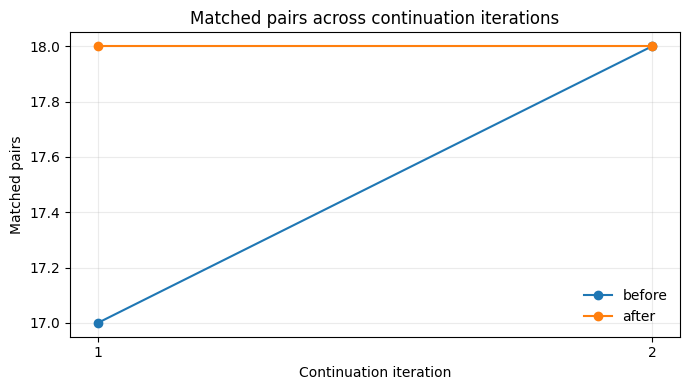

label column: cluster
points in view before/after: 83546 / 83546 of 83546
matched pairs shown: 18


saved result visualization PNG: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/iterative_lddmm_before_after_all_points.png
saved result visualization PDF: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/iterative_lddmm_before_after_all_points.pdf


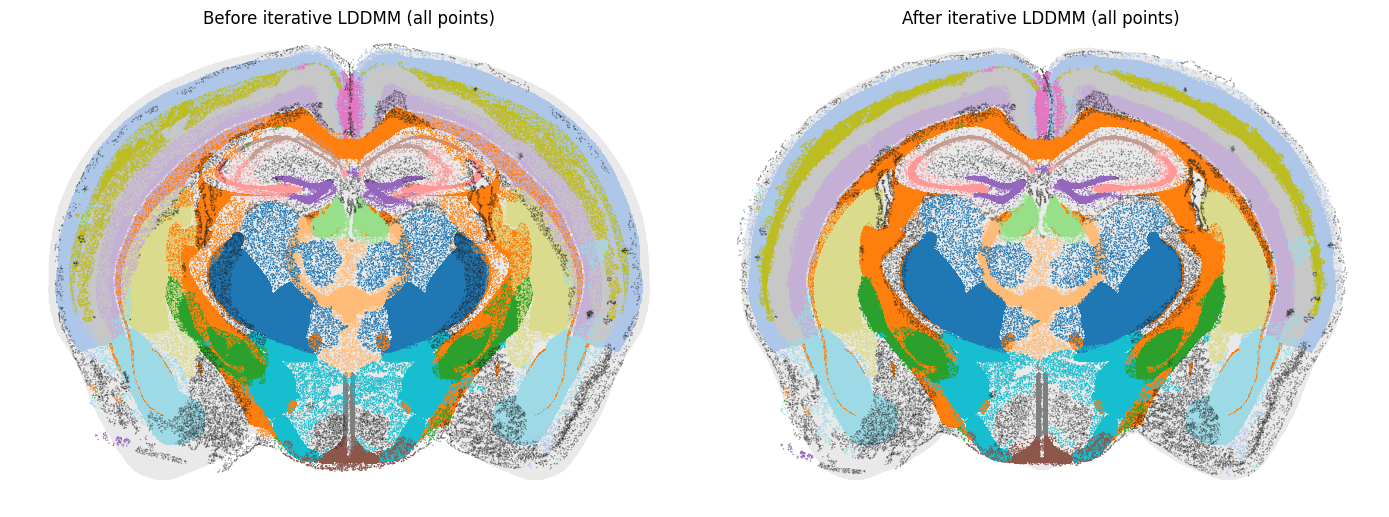

saved final alignment outputs to: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment
final aligned points: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/final_aligned_all_points.csv
final matched pairs: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/matched_pairs_final_stage.csv
all-stage matched pairs: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/matched_pairs_all_stages.csv
stage summary: /path/to/spAlignDE/tutorials/cross_modality/atlas/output/alignment/iterative_alignment_stage_summary.csv


Mode: fresh package run
Aligned observations: 83,546
Final matched structure pairs: 18
Alignment runtime: 13.3 minutes
Peak GPU memory allocation: 0.862 GiB


In [3]:
alignment_output = OUTPUT_DIR / "alignment"
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
alignment_start = time.perf_counter()
result = spAlignDE.align_st_to_allen_atlas(
    adata,
    atlas,
    config=config,
    cluster_key="cluster",
    output_dir=alignment_output,
)
if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed_seconds = time.perf_counter() - alignment_start
peak_cuda_gib = (
    torch.cuda.max_memory_allocated() / (1024**3)
    if torch.cuda.is_available()
    else 0.0
)
runtime_metrics = {
    "elapsed_seconds": elapsed_seconds,
    "elapsed_minutes": elapsed_seconds / 60.0,
    "peak_cuda_memory_allocated_gib": peak_cuda_gib,
    "cuda_available": torch.cuda.is_available(),
}
(alignment_output / "end_to_end_runtime_cuda_metrics.json").write_text(
    json.dumps(runtime_metrics, indent=2)
)

print("Mode: fresh package run")
print("Aligned observations:", f"{result.adata.n_obs:,}")
print("Final matched structure pairs:", len(result.matched_pairs))
print(f"Alignment runtime: {runtime_metrics['elapsed_minutes']:.1f} minutes")
print(f"Peak GPU memory allocation: {runtime_metrics['peak_cuda_memory_allocated_gib']:.3f} GiB")

## 3. Inspect structure correspondences

The three-level package workflow starts with at least seven coarse structures
and then makes only the ST partition progressively finer. The executed output
reports the exact scheduled-stage and post-continuation pair counts. Automatic
pairing uses spatial masks and the full eligible Atlas hierarchy at every
stage; no shared molecular features or structure-specific override is used.

In [4]:
display(result.stage_summary)

pair_columns = [
    column
    for column in (
        "cluster",
        "candidate_name",
        "pair_type",
        "align_score_gated",
        "dice",
        "area_sim",
        "chamfer_dist",
        "asd",
    )
    if column in result.matched_pairs
]
display(result.matched_pairs[pair_columns].head(20))

,stage,label_col,is_final_stage,n_pairs,lddmm_ran
0,1,cluster_level_k7,False,3,True
1,2,cluster_level_k16,False,8,True
2,3,cluster,True,16,True


,cluster,candidate_name,pair_type,align_score_gated,dice,area_sim,chamfer_dist,asd
0,0,DORsm,leaf,0.540490,0.599991,0.469082,27.388456,28.813592
1,1,L2/3,layer,0.844855,0.765078,0.908184,10.601866,10.582985
2,10,fiber tracts,leaf,0.650164,0.644581,0.589108,25.415712,35.072887
3,11,ILM,leaf,0.727866,0.543978,0.731093,13.311190,14.765596
4,12,PAL,leaf,0.757397,0.783862,0.788481,8.861050,8.675589
5,17,EPI,leaf,0.913706,0.838588,0.974278,3.466917,3.506319
6,18,CA3sp,leaf,0.837020,0.814408,0.780639,1.781286,1.789158
7,19,DG-sg,leaf,0.865360,0.745976,0.871059,3.138261,3.204791
8,2,L6a,layer,0.916904,0.822612,0.984862,6.323685,6.467799
9,20,ARH,leaf,0.619718,0.594467,0.512821,11.190244,13.752681


## 4. Before and after structure-guided S-LDDMM

The left panel shows the globally pre-aligned ST point cloud. The right panel
shows the final coordinates after coarse-to-fine S-LDDMM. Every matched ST
cluster and its paired Allen structure use the same fixed, structure-name
color. The palette preserves the clearer colors from the validated paper
notebook instead of changing when cluster numbers or pair-table order change.
Unmatched atlas regions are light gray and unmatched ST cells are dark gray.

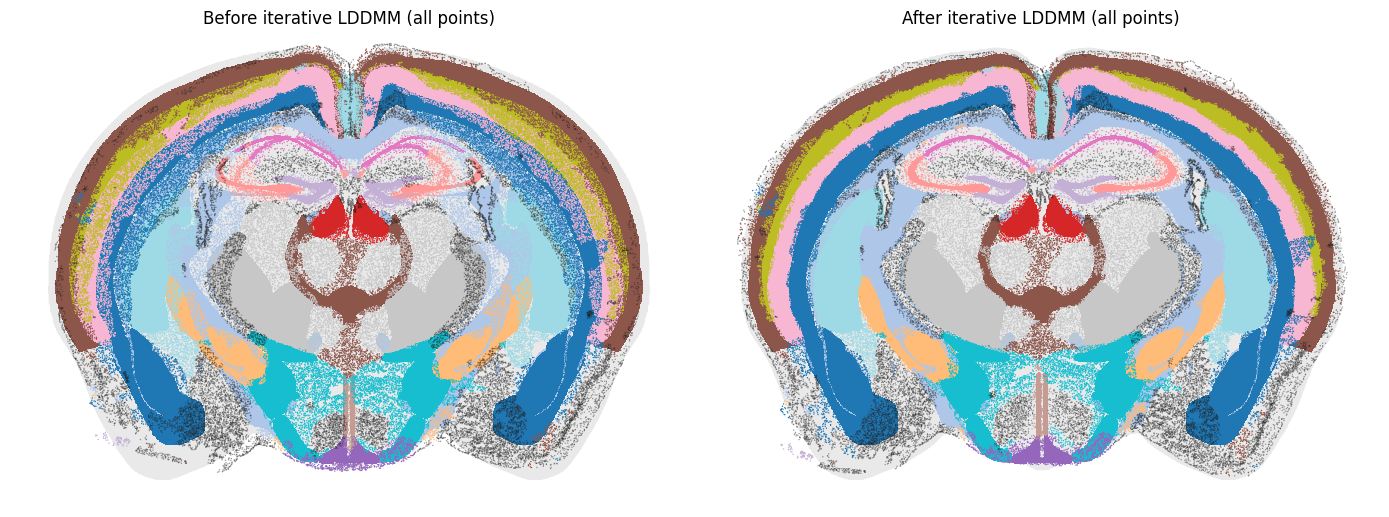

In [5]:
structure_color_map = spAlignDE.load_atlas_structure_color_map()
fig, axes = spAlignDE.plot_st_atlas_alignment(
    result,
    cluster_key="cluster",
    structure_color_map=structure_color_map,
    point_size=1.0,
    figsize=(14, 7),
)
fig.savefig(FIGURE_DIR / "st_to_allen_before_after.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "st_to_allen_before_after.svg", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "st_to_allen_before_after.pdf", bbox_inches="tight")
plt.show()

## 5. Transfer Allen labels to aligned ST cells

After alignment, each final `(x_aligned, y_aligned)` location samples the
annotation image. Atlas ID 0 is retained as background/unlabeled instead of
being replaced by a nearby region. The executed summary below reports the
fresh package result rather than loading cached paper coordinates.

The two panels use the original notebook's fixed label-color table: label 0 is
white, every Allen label has one reproducible color, and transferred ST labels
reuse exactly those colors.

,value
all ST cells,83546.000000
non-background Allen label,82987.000000
background / unlabeled,559.000000
unlabeled fraction,0.006691


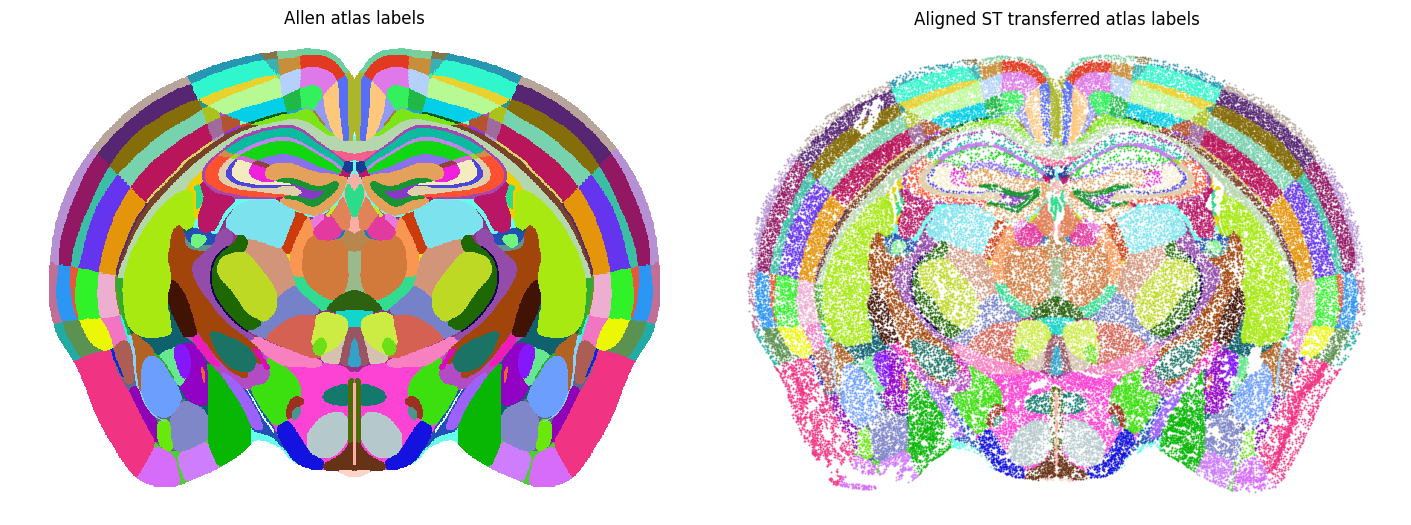

In [6]:
transfer_summary = pd.Series(
    {
        "all ST cells": result.adata.n_obs,
        "non-background Allen label": int(result.adata.obs["atlas_label_transferred"].sum()),
        "background / unlabeled": int((~result.adata.obs["atlas_label_transferred"]).sum()),
        "unlabeled fraction": float((~result.adata.obs["atlas_label_transferred"]).mean()),
    },
    name="value",
)
display(transfer_summary.to_frame())

color_map_path = result.output_dir / (
    f"atlas_z{result.atlas.slice_index}_white_label_color_map_for_transfer_labels.csv"
)
label_color_map = spAlignDE.load_atlas_label_color_map(
    color_map_path,
    atlas=result.atlas,
)
fig, axes = spAlignDE.plot_atlas_label_transfer(
    result,
    color_map=label_color_map,
    point_size=2.0,
    point_alpha=0.8,
    figsize=(14, 7),
)
fig.savefig(FIGURE_DIR / "st_to_allen_label_transfer.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "st_to_allen_label_transfer.svg", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "st_to_allen_label_transfer.pdf", bbox_inches="tight")
plt.show()

## 6. Output contract

The returned AnnData preserves `X` and `obsm["spatial"]` and adds:

- `obs["x_prealigned"]`, `obs["y_prealigned"]` — whole-mask IoU result;
- `obs["x_aligned"]`, `obs["y_aligned"]` — final S-LDDMM coordinates;
- `obs["atlas_label_id"]`, `obs["atlas_label_acronym"]`,
  `obs["atlas_label_name"]`, `obs["atlas_label_transferred"]` — sampled Allen
  annotation; and
- `uns["spAlignDE"]["st_to_allen_atlas"]` — parameters and provenance for a
  fresh package run.

`result.matched_pairs` and `result.stage_summary` retain the structure-level
QC tables. A fresh run also writes the aligned H5AD, pair tables, hierarchy
table, and PNG/PDF alignment QC files under the chosen `output_dir`.

In [7]:
coordinate_columns = ["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]
label_columns = [
    "atlas_label_id",
    "atlas_label_acronym",
    "atlas_label_name",
    "atlas_label_transferred",
]
display(result.adata.obs[coordinate_columns + label_columns].head())

metrics_path = result.output_dir / "end_to_end_runtime_cuda_metrics.json"
if metrics_path.is_file():
    metrics = json.loads(metrics_path.read_text())
    print(f"Fresh end-to-end runtime: {metrics['elapsed_minutes']:.1f} minutes")
    print(f"Peak GPU memory allocation: {metrics['peak_cuda_memory_allocated_gib']:.3f} GiB")

,x_prealigned,y_prealigned,x_aligned,y_aligned,atlas_label_id,atlas_label_acronym,atlas_label_name,atlas_label_transferred
cell_id,,,,,,,,
149164679103246548309819743981609972453,10070.702197,2047.091006,10052.424305,2118.963980,961,PIR,Piriform area,True
215843146921706462965382248182021894607,10140.473843,2117.309107,10124.670898,2191.676990,961,PIR,Piriform area,True
230248905804673613678286091156141465134,10122.405859,2064.660145,10105.996302,2139.076481,961,PIR,Piriform area,True
237155298815097057940587033798543926454,10093.291263,2023.639780,10076.598750,2096.719572,961,PIR,Piriform area,True
256099454901769634241742157204636917386,10099.394726,2029.208897,10082.790473,2102.626222,961,PIR,Piriform area,True


Fresh end-to-end runtime: 13.3 minutes
Peak GPU memory allocation: 0.862 GiB
